# Proyek Analisis Data: [BIKE SHARING DATASET]
- **Nama:** [Achmad Zain Nur Rahman]
- **Email:** [zainrahman680@gmail.com]
- **ID Dicoding:** [Achmad Zain Nur Rahman]

## Menentukan Pertanyaan Bisnis

1. Apakah terdapat hubungan antara jumlah sepeda yang dipinjam dengan kondisi musim (season)?

2. Apakah terdapat hubungan antara perbedaan hari dengan jumlah sepeda yang dipinjam?

## Import Semua Packages/Library yang Digunakan

Import library **numpy dan pandas** yang digunakan untuk **mengolah data matematika.**
Import library **matplotlib dan seaborn** untuk **visualisasi data menjadi grafik.**




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

tahapan **pembacaan dataset** dengan **memasukkan link github**

In [ ]:
data_link= "https://raw.githubusercontent.com/zainzain22/sepeda/refs/heads/main/day.csv"
df_sepeda = pd.read_csv(data_link)


### Assessing Data

**Mengubah kolom season** dari yang hanya 1-4 diubah menjadi text berupa **winter, spring, summer, dan fall.**

**Mengubah kolom weekday** dari yang hanya 0-6 diubah menjadi text **urutan hari dari minggu-sabtu.**

In [ ]:
season_mapping = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
df_sepeda['season'] = df_sepeda['season'].map(season_mapping)
weekday_mapping = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
df_sepeda['weekday'] = df_sepeda['weekday'].map(weekday_mapping)

### Cleaning Data

pada bagian cleaning akan dilakukan **penghapusan data duplicate dan missing value** namun karena hanya menggunakan season, weekday dan cnt maka tidak ada yang perlu dibersihkan karena **data telah sesuai dari jumlah dan juga type data**.

In [ ]:
df_sepeda.info()
df_sepeda.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    object 
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    object 
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(9), object(3)
memory usage: 91.5+ KB


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Winter,0,1,0,Saturday,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Winter,0,1,0,Sunday,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Winter,0,1,0,Monday,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Winter,0,1,0,Tuesday,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Winter,0,1,0,Wednesday,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Exploratory Data Analysis (EDA)

### Explore ...

penjelasan tabel secara keseluruhan guna **mencari nilai umum di setiap kolom.**

In [ ]:
df_sepeda.describe()

,instant,yr,mnth,holiday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,0.500684,6.519836,0.028728,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,0.500342,3.451913,0.167155,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,0.000000,4.000000,0.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,1.000000,7.000000,0.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,1.000000,10.000000,0.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,1.000000,12.000000,1.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
1. didapatkan info bahwa **tidak ada missing value ataupun duplicate data** karena seluruh **value dari count adalah sama di setiap kolom.**
2. jika meninjau nilai max dan min dari data cnt terlihat bahwa:

nilai min: 22

nilai max: 8714

**mengelompokkan data berdasarkan season** dan menghitung total cnt di setiap season

**Mengelompokan data berdasarkan weekday** dan menghitung total cnt di setiap weekday

In [ ]:
season_cnt_total = df_sepeda.groupby('season')['cnt'].sum().reset_index()
weekday_cnt_total = df_sepeda.groupby('weekday')['cnt'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_sepeda['weekday'] = pd.Categorical(df_sepeda['weekday'], categories=ordered_days, ordered=True)



## Visualization & Explanatory Analysis

tabel season dan tabel weekday dihias untuk meningkatkan segi desain.

In [ ]:
season_palette = sns.color_palette(["#003f5c", "#375a8c", "#7a8dbe", "#bcdef0"])  # Dark blue to standard blue
weekday_palette = sns.color_palette(["#004d00", "#006600", "#338a00", "#66b300"])  # Dark green to standard green



### Pertanyaan 1: Apakah terdapat hubungan antara jumlah sepeda yang dipinjam dengan kondisi musim (season)?

**BARPLOT PERTANYAAN 1**

visualisasi dilakukan dengan menggunakan bar plot dengan **ukuran 10 x 6 inci**.

sns.barplot adalah tahapan pembuatan grafik bar plot dengan menggunakan data **season_cnt_total sebagai nilai yang ditampilkan**.

disisi lain penggunaan **plt.grid ditujukan agar grafik menjadi rapi** dan **plt.show adalah bagian akhir untuk menunjukkan grafik** yang sudah dirancang.


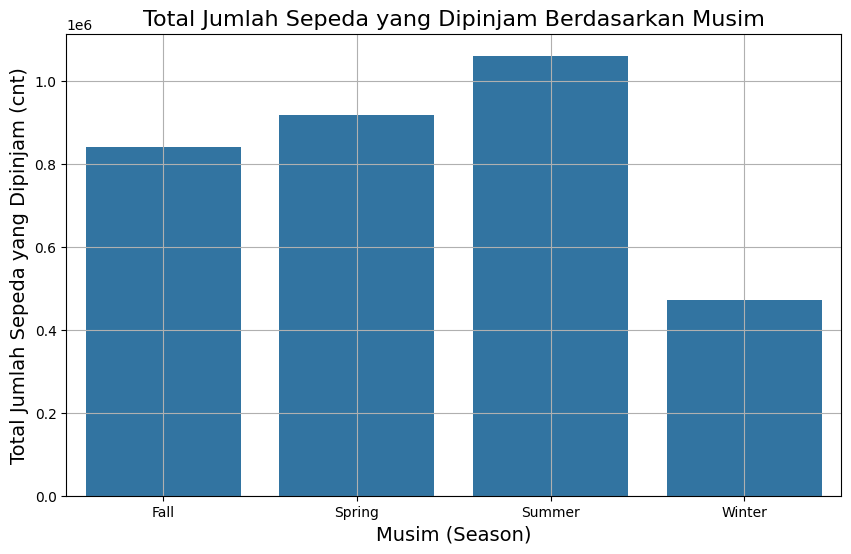

In [ ]:

plt.figure(figsize=(10, 6))
gradient_palette_season = sns.color_palette(["#003f5c", "#375a8c", "#7a8dbe", "#bcdef0"])
sns.barplot(data=season_cnt_total, x='season', y='cnt')
plt.title('Total Jumlah Sepeda yang Dipinjam Berdasarkan Musim', fontsize=16)
plt.xlabel('Musim (Season)', fontsize=14)
plt.ylabel('Total Jumlah Sepeda yang Dipinjam (cnt)', fontsize=14)
plt.grid(True)
plt.show()


**Insight:**
1. grafik bar di atas menunjukkan bahwa pada musim summer terlihat bahwa terdapat nilai tertinggi dibanding 3 musim yang lain  yaitu pada titik 1,25. ini menunjukkan bahwa banyak sekali orang yang menyewa sepeda di musim summer.

2. disisi lain pada musim winter hanya sedikit orang yang menyewa sepeda dibanding ke 3 musim yang lain nilai tersebut menunjukkan di titik 0,45.

**JAWABAN DARI PERTANYAAN**

grafik menunjukkan dengan jelas bahwa terdapat perbedaan jumlah dari peminjam sepeda dari setiap musim. terlihat bahwa musim summber memiliki nilai tertinggi dari jumlah peminjam sepeda.

Perusahaan seharusnya menyiapkan lebih banyak sepeda pada musim summer agar tidak terdapat antri yang panjang.

namun pada musim winter sebaiknya perusahaan lebih fokus melakukan perbaikan sepeda karena telah sering digunakan pada musim sebelumnya, disisi lain pada musim winter memang peminjam sepeda hanya sedikit.

**BOXPLOT PERTANYAAN 1**

visualisasi dilakukan dengan menggunakan bar plot dengan ukuran 10 x 6 inci.

sns.boxplot adalah tahapan pembuatan grafik box plot dengan menggunakan data dataset sebagai nilai yang ditampilkan.

disisi lain penggunaan plt.grid ditujukan agar grafik menjadi rapi dan plt.show adalah bagian akhir untuk menunjukkan grafik yang sudah dirancang


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


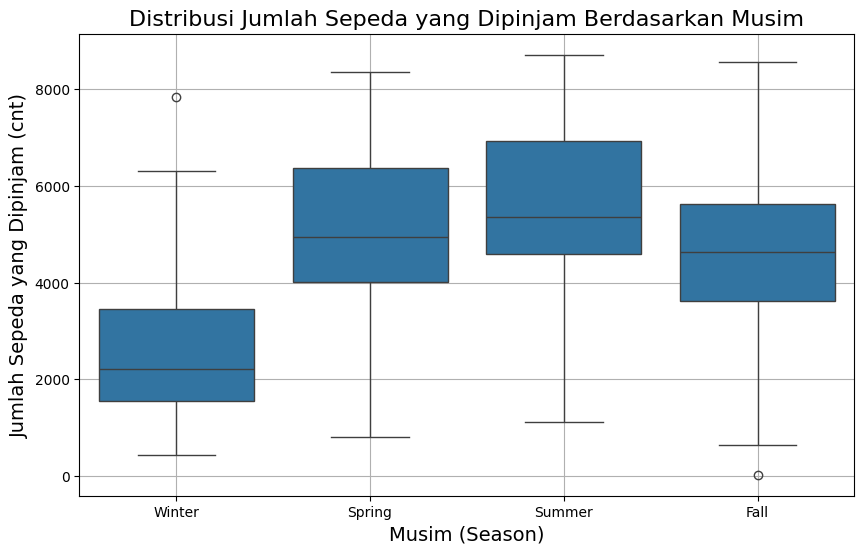

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sepeda, x='season', y='cnt')
plt.title('Distribusi Jumlah Sepeda yang Dipinjam Berdasarkan Musim', fontsize=16)
plt.xlabel('Musim (Season)', fontsize=14)
plt.ylabel('Jumlah Sepeda yang Dipinjam (cnt)', fontsize=14)
plt.grid(True)
plt.show()


**Insight:**
1. menggunakan boxplot ditujukan agar didapatkan keseluruhan data dari nilai max dan min serta nilai quartil di setiap musimnya.
2. pada musim winter terlihat bahwa nilai mean sangat jauh dari nilai maximum yang artinya tidak tepat ditengah tengah nilai. disisi lain terdapat outlier di atas nilai maximum.
3. pada musim fall terlihat sangat baik untuk nilai mean karena tepat pada tengah antara max dan min ini menandakan bahwa nilai terbagi rata namun masih ada outlier di nilai 0.

**JAWABAN DARI PERTANYAAN**
grafik diatas menjelaskan hubungan antara musim dengan jumlah peminjam sepeda yang sangat detail karena memperlihatkan keseluruhan nilai dan terbukti bahwa musim summer memiliki nilai tertinggi dari object peminjam sepeda.

### Pertanyaan 2: Apakah terdapat hubungan antara perbedaan hari dengan jumlah sepeda yang dipinjam?



**LINEPLOT PERTANYAAN 2**

visualisasi dilakukan dengan menggunakan bar plot dengan ukuran 10 x 6 inci.

sns.lineplot adalah tahapan pembuatan grafik line plot dengan menggunakan data dataset sebagai nilai yang ditampilkan.

disisi lain penggunaan plt.grid ditujukan agar grafik menjadi rapi dan plt.show adalah bagian akhir untuk menunjukkan grafik yang sudah dirancang


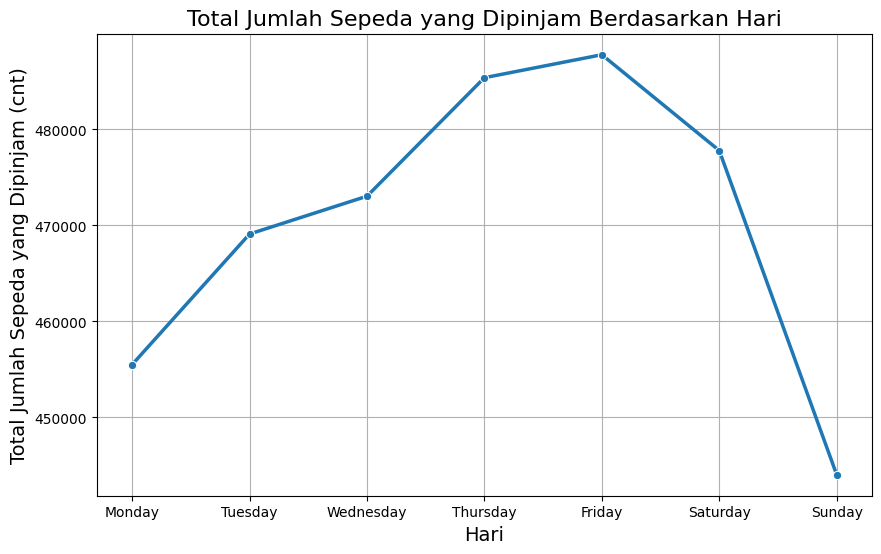

In [ ]:
plt.figure(figsize=(10, 6))
gradient_palette_weekday = sns.color_palette(["#004d00", "#006600", "#338a00", "#66b300"])
sns.lineplot(x=weekday_cnt_total['weekday'], y=weekday_cnt_total['cnt'], marker='o', linewidth=2.5)
plt.title('Total Jumlah Sepeda yang Dipinjam Berdasarkan Hari', fontsize=16)
plt.xlabel('Hari', fontsize=14)
plt.ylabel('Total Jumlah Sepeda yang Dipinjam (cnt)', fontsize=14)
plt.grid(True)
plt.show()


**insight**:

grafik garis berhasi menunjukkan perbedaan nilai rata rata dari hari ke hari. terlihat bahwa hari minggu adalah peminjam sepeda sangatlah minim yaitu hampir mencapai 440000 saja. disisi lain hari jumat adalah angka tertinggi peminjam sepeda yang menjadi nilai maximum yaitu mencapai hampir 49000.


**JAWABAN DARI PERTANYAAN**

terdapat hubungan dari perbedaan hari dengan jumlah peminjam sepeda yaitu pada weekday terlihat bahwa peminjam sepeda terus meningkat berbeda dengan weekend yang nilainya drastis menurun.

perusahaan sebaiknya mempersiapkan banyak sepeda di weekday agar tidak terjadi antri yang panjang. namun pada weekend perusahaan sebaiknya melakukan pengecekan kondisi sepeda agar saat memasuki hari senin yang selanjutnya maka semua sepeda telah siap untuk digunakan kembali.

visualisasi dilakukan dengan menggunakan bar plot dengan ukuran 10 x 6 inci.

sns.boxplot adalah tahapan pembuatan grafik box plot dengan menggunakan data dataset sebagai nilai yang ditampilkan.

disisi lain penggunaan plt.grid ditujukan agar grafik menjadi rapi dan plt.show adalah bagian akhir untuk menunjukkan grafik yang sudah dirancang


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


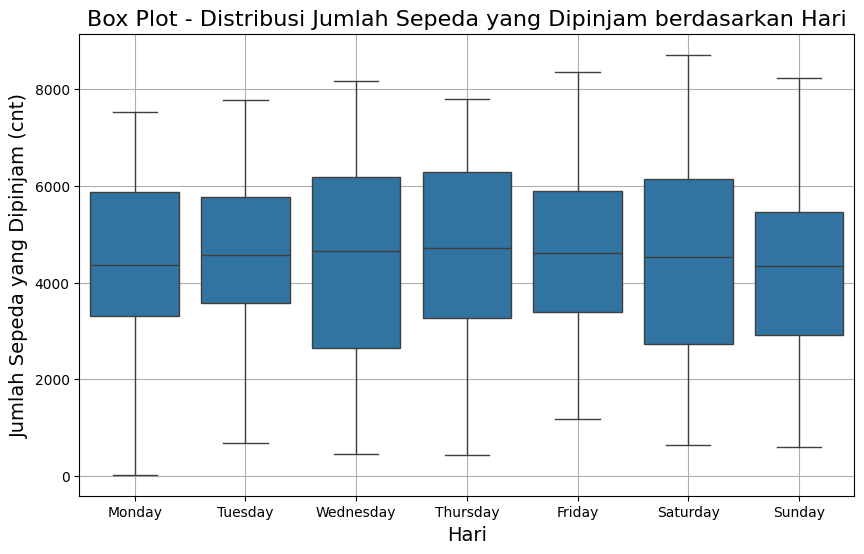

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sepeda, x='weekday', y='cnt', order=ordered_days)  # Menambahkan parameter 'order' untuk mengatur urutan hari
plt.title('Box Plot - Distribusi Jumlah Sepeda yang Dipinjam berdasarkan Hari', fontsize=16)
plt.xlabel('Hari', fontsize=14)
plt.ylabel('Jumlah Sepeda yang Dipinjam (cnt)', fontsize=14)
plt.grid(True)
plt.show()


**Insight:**
1. grafik box plot sangatlah membantu dalam melihat persebaran data menggunakan batasan maximum dan minimum dengan bantuan nilai quarti.
2. pada grafik terlihat bahwa rata rata peminjaman sepeda di setiap harinya hampir sama yaitu berkisar 430000.
3. begitupun nilai quartil 3 atau nilai 75% dari setiap hari juga hampir mirip yaitu berkisar 6000 kecuali hari minggu.

**JAWABAN DARI PERTANYAAN**
terlihat bahwa terdapat perbedaan jumlah peminjam sepeda di setiap harinya. itu juga menandakan bahwa liburan di akhir pekan menyebabkan penurunan jumlah peminjam sepeda.

perusahaan sebaiknya mempersiapkan banyak sepeda di weekday agar tidak terjadi antri yang panjang. namun pada weekend perusahaan sebaiknya melakukan pengecekan kondisi sepeda agar saat memasuki hari senin yang selanjutnya maka semua sepeda telah siap untuk digunakan kembali.

**ANALISIS TAMBAHAN**

PENGUNAAN **CLUSTERING HEATMAP** BERDASARKAN HUBUNGAN MUSIM DENGAN JUMLAH CNT

melihat persebaran data dengan rentang nilai rendah hingga sangat tinggi.
heatmap memudahkan pembaca dalam memahami persebaran nilai agar tau di titik mana nilai tersebut terkumpul.


Hasil Clustering:
      cnt  cluster
0     985        0
1     801        0
2    1349        0
3    1562        0
4    1600        0
..    ...      ...
726  2114        0
727  3095        0
728  1341        0
729  1796        0
730  2729        0

[731 rows x 2 columns]


<ipython-input-14-a741f01c9633>:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df_sepeda.groupby(['season', 'cnt_binned'])['cnt'].sum().unstack().fillna(0)


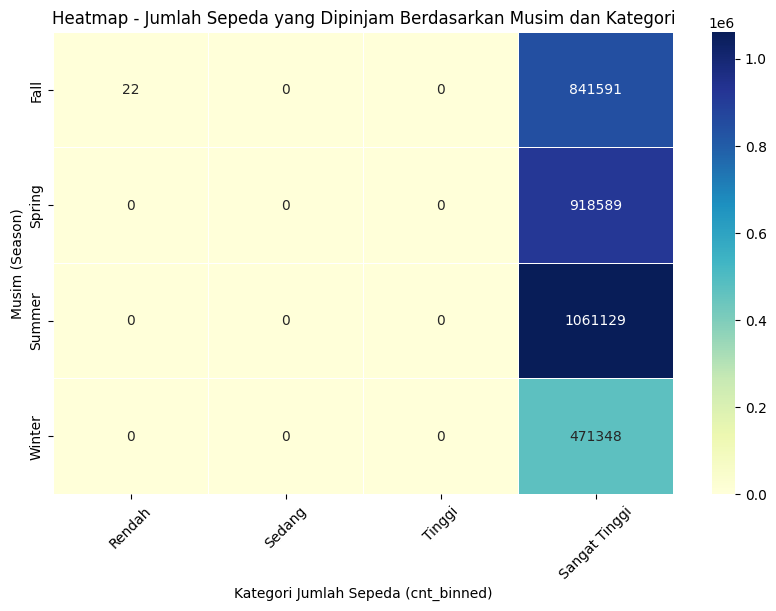

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
%matplotlib inline

bins = [0, 100, 200, 300, float('inf')]
labels = ['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
df_sepeda['cnt_binned'] = pd.cut(df_sepeda['cnt'], bins=bins, labels=labels, right=False)

# Clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_sepeda[['cnt']])

# Penggunaan KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df_sepeda['cluster'] = kmeans.fit_predict(scaled_data)

print("Hasil Clustering:")
print(df_sepeda[['cnt', 'cluster']])

# Visualisasi HEATMAP
heatmap_data = df_sepeda.groupby(['season', 'cnt_binned'])['cnt'].sum().unstack().fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlGnBu', linewidths=0.5)
plt.title('Heatmap - Jumlah Sepeda yang Dipinjam Berdasarkan Musim dan Kategori')
plt.xlabel('Kategori Jumlah Sepeda (cnt_binned)')
plt.ylabel('Musim (Season)')
plt.xticks(rotation=45)
plt.show()


## Conclusion


Pertanyaan 1: Apakah terdapat hubungan antara jumlah sepeda yang dipinjam dengan kondisi musim (season)?

pada kedua grafik terlihat jelas bahwa jumlah sepeda yang dipinjam memang dipengaruhi dari musim yang artinya peminjam sepeda juga memperhatikan kebutuhan dari segi musim.

Pertanyaan 2: Apakah terdapat hubungan antara perbedaan hari dengan jumlah sepeda yang dipinjam?

pada kedua grafik terlihat bahwa perbedaan hari memiliki nilai yang berbeda untuk jumlah sepeda yang dipinjam. grafik menunjukkan bahwa nilai di hari sabtu minggu sangatlah rendah karena liburan.